# **Plotting Script: ENSO Transition Probability**

Output: 

1) /home/563/ft3359/FT-Honours/Honours_Paper/Figures/TransProb_all_eruptions.png"

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from matplotlib.lines import Line2D


# FONT
mpl.rcParams["font.family"]     = "sans-serif"
mpl.rcParams["font.sans-serif"] = ["Arial", "Helvetica", "DejaVu Sans"]


# INPUT / OUTPUT
TABLE_DIR = "/home/563/ft3359/FT-Honours/Honours_Paper/Transition_Prob/All_Eruptions"
MODEL_CSV = os.path.join(TABLE_DIR, "TransProb_Models.csv")
RECON_CSV = os.path.join(TABLE_DIR, "TransProb_Recons.csv")
OUT_PNG   = "/home/563/ft3359/FT-Honours/Honours_Paper/Figures/TransProb_all_eruptions.png"


# SETTINGS
PHASES = ["El Niño", "Neutral", "La Niña"]

# Colour Set
PHASE_COLORS = {
    "El Niño": "#D55E00",
    "Neutral": "#A8B4C0",
    "La Niña": "#0072B2",
}

# Panel labels
LEFT_ROW_LABEL  = "(a) Models"
RIGHT_ROW_LABEL = "(b) Reconstructions"

ANNOTATE_MIN_FRAC = 0.05

# Donut geometry
OUTER_RADIUS  = 1.30
INNER_RADIUS  = 0.88
RING_WIDTH    = 0.36
ERUPT_LABEL_R = 1.13
BASE_LABEL_R  = 0.71

# Font sizes
PCT_FONTSIZE          = 14
TITLE_FONTSIZE        = 17
ROW_LABEL_FONTSIZE    = 17
LEGEND_FONTSIZE       = 15
LEGEND_TITLE_FONTSIZE = 16

In [2]:
# HELPERS

def sanitize_prob_vector(p):
    p = np.asarray(p, dtype=float).copy()
    p[~np.isfinite(p)] = 0.0
    p[p < 0]           = 0.0
    s = p.sum()
    if s > 0:
        p /= s
    else:
        p[:] = 0.0
    return p


def read_wlp_csv(csv_path):
    df = pd.read_csv(csv_path)
    needed = {
        "start_phase",
        "baseline_EN", "baseline_N", "baseline_LN",
        "eruption_EN", "eruption_N", "eruption_LN",
    }
    missing = sorted(needed - set(df.columns))
    if missing:
        raise KeyError(f"CSV missing columns {missing}: {csv_path}")

    probs_base  = {}
    probs_erupt = {}

    for sp in PHASES:
        row = df[df["start_phase"] == sp]
        if row.empty:
            probs_base[sp]  = np.zeros(3, dtype=float)
            probs_erupt[sp] = np.zeros(3, dtype=float)
            continue
        r = row.iloc[0]
        probs_base[sp]  = sanitize_prob_vector(
            [r["baseline_EN"], r["baseline_N"], r["baseline_LN"]]
        )
        probs_erupt[sp] = sanitize_prob_vector(
            [r["eruption_EN"], r["eruption_N"], r["eruption_LN"]]
        )

    return probs_base, probs_erupt


def donut_on_ax(ax, pB, pE, title):
    colors = [PHASE_COLORS["El Niño"], PHASE_COLORS["Neutral"], PHASE_COLORS["La Niña"]]

    if pB.sum() <= 0 and pE.sum() <= 0:
        ax.text(0, 0, "No transitions", ha="center", va="center", fontsize=PCT_FONTSIZE)
        ax.set_title(title, fontsize=TITLE_FONTSIZE)
        ax.set_aspect("equal")
        ax.axis("off")
        return

    # Outer ring = eruption
    wedgesE = []
    if pE.sum() > 0:
        wedgesE, _ = ax.pie(
            pE,
            radius=OUTER_RADIUS,
            colors=colors,
            startangle=90,
            wedgeprops=dict(width=RING_WIDTH, edgecolor="white"),
        )

    # Inner ring = baseline
    wedgesB = []
    if pB.sum() > 0:
        wedgesB, _ = ax.pie(
            pB,
            radius=INNER_RADIUS,
            colors=colors,
            startangle=90,
            wedgeprops=dict(width=RING_WIDTH, edgecolor="white"),
        )

    # Percentage labels
    for i in range(3):
        if i < len(wedgesE) and pE[i] >= ANNOTATE_MIN_FRAC:
            ang = (wedgesE[i].theta1 + wedgesE[i].theta2) / 2
            ax.text(
                ERUPT_LABEL_R * np.cos(np.deg2rad(ang)),
                ERUPT_LABEL_R * np.sin(np.deg2rad(ang)),
                f"{100*pE[i]:.0f} %",
                ha="center", va="center",
                fontsize=PCT_FONTSIZE, color="white", weight="bold",
            )

        if i < len(wedgesB) and pB[i] >= ANNOTATE_MIN_FRAC:
            ang = (wedgesB[i].theta1 + wedgesB[i].theta2) / 2
            ax.text(
                BASE_LABEL_R * np.cos(np.deg2rad(ang)),
                BASE_LABEL_R * np.sin(np.deg2rad(ang)),
                f"{100*pB[i]:.0f} %",
                ha="center", va="center",
                fontsize=PCT_FONTSIZE, color="white", weight="bold",
            )

    lim = OUTER_RADIUS + 0.20
    ax.set_xlim(-lim, lim)
    ax.set_ylim(-lim, lim)
    ax.set_title(title, fontsize=TITLE_FONTSIZE)
    ax.set_aspect("equal")
    ax.axis("off")

Saved: /home/563/ft3359/FT-Honours/Honours_Paper/Figures/TransProb_all_eruptions.png


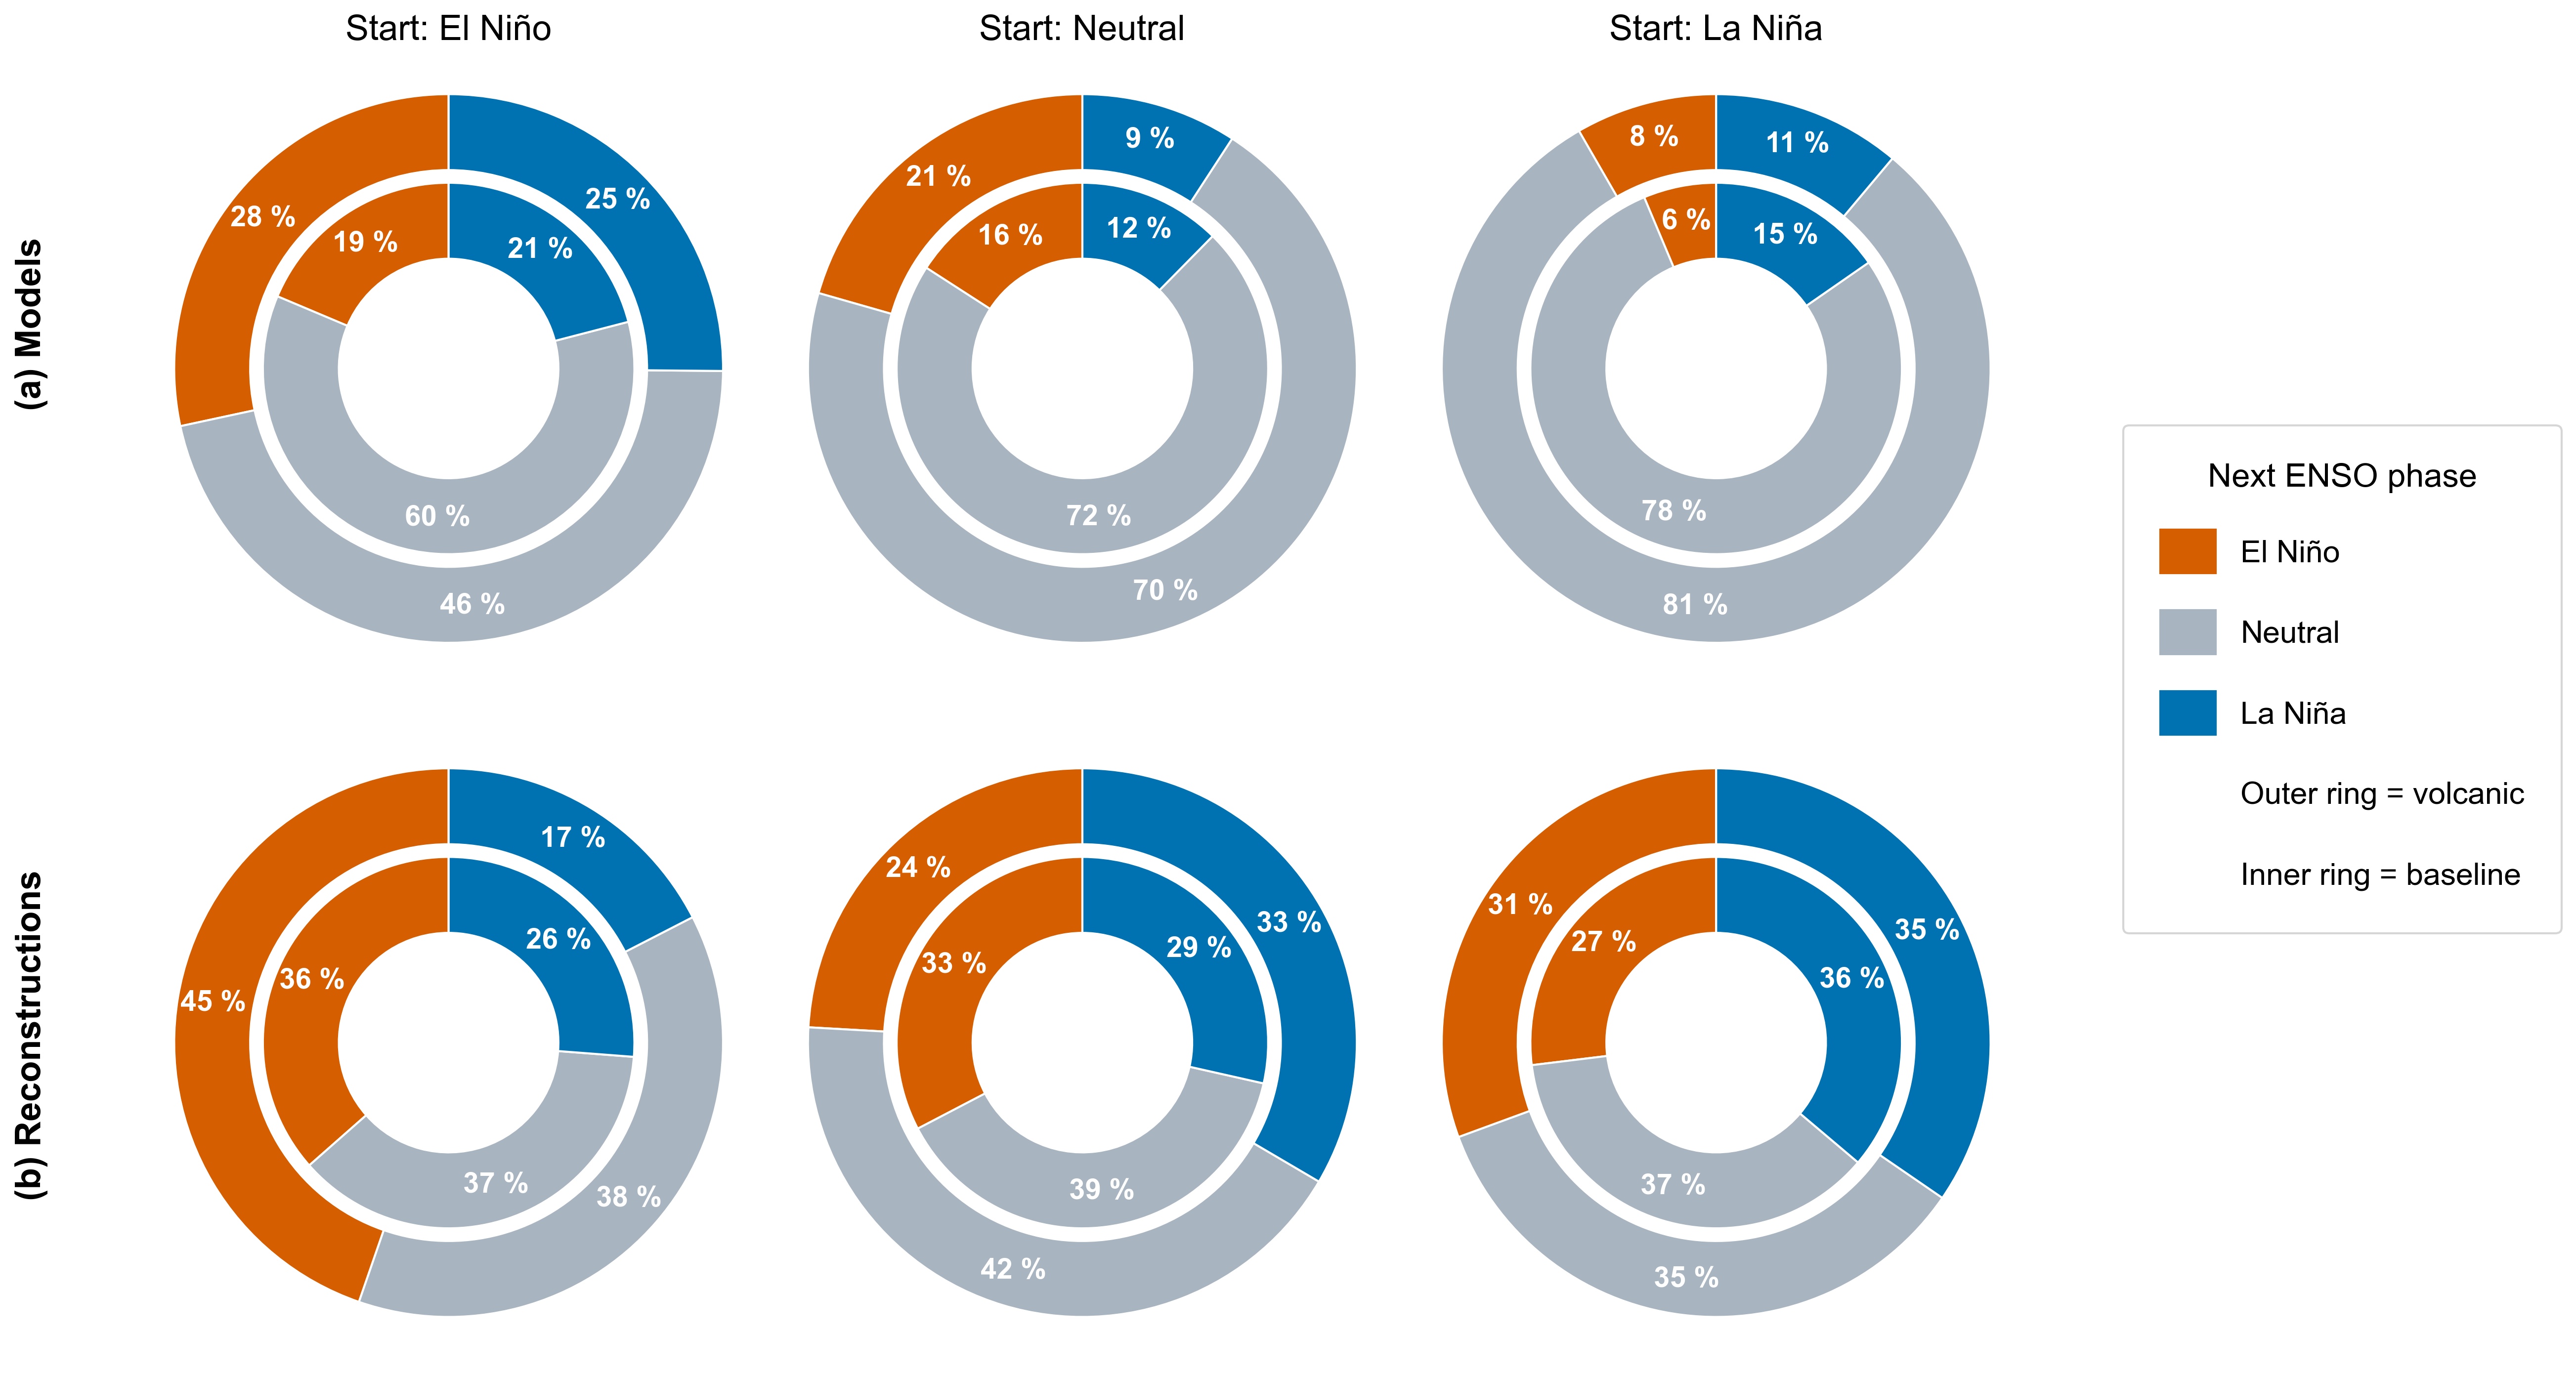

In [3]:
# LOAD DATA

for p in [MODEL_CSV, RECON_CSV]:
    if not os.path.isfile(p):
        raise FileNotFoundError(f"Missing input CSV: {p}")

model_base, model_erupt = read_wlp_csv(MODEL_CSV)
recon_base, recon_erupt = read_wlp_csv(RECON_CSV)


# PLOT

fig, axes = plt.subplots(2, 3, figsize=(16, 10), dpi=300)

# Row 0: models
for j, sp in enumerate(PHASES):
    donut_on_ax(
        axes[0, j],
        model_base.get(sp,  np.zeros(3)),
        model_erupt.get(sp, np.zeros(3)),
        title=f"Start: {sp}",
    )

# Row 1: reconstructions
for j, sp in enumerate(PHASES):
    donut_on_ax(
        axes[1, j],
        recon_base.get(sp,  np.zeros(3)),
        recon_erupt.get(sp, np.zeros(3)),
        title="",
    )

# Left-side row labels
fig.text(0.02, 0.74, LEFT_ROW_LABEL,  rotation=90, va="center", ha="left",
         fontsize=ROW_LABEL_FONTSIZE, fontweight="bold")
fig.text(0.02, 0.26, RIGHT_ROW_LABEL, rotation=90, va="center", ha="left",
         fontsize=ROW_LABEL_FONTSIZE, fontweight="bold")

# Legend
color_handles = [Rectangle((0, 0), 1, 1, color=PHASE_COLORS[ph])
                 for ph in ["El Niño", "Neutral", "La Niña"]]
color_labels  = ["El Niño", "Neutral", "La Niña"]

blank         = Line2D([], [], linestyle="none", marker="none")
ring_handles  = [blank, blank]
ring_labels   = ["Outer ring = volcanic", "Inner ring = baseline"]

all_handles = color_handles + ring_handles
all_labels  = color_labels  + ring_labels

leg = fig.legend(
    all_handles,
    all_labels,
    title="Next ENSO phase",
    loc="center right",
    bbox_to_anchor=(1.10, 0.5),
    fontsize=LEGEND_FONTSIZE,
    title_fontsize=LEGEND_TITLE_FONTSIZE,
    labelspacing=1.2,
    handlelength=1.8,
    handleheight=1.8,
    handletextpad=0.8,
    borderpad=1.2,
    frameon=True,
)

for handle, text in zip(leg.legend_handles, leg.get_texts()):
    if text.get_text() in ring_labels:
        handle.set_visible(False)

plt.tight_layout(rect=[0.06, 0.02, 0.88, 0.97])

os.makedirs(os.path.dirname(OUT_PNG), exist_ok=True)
fig.savefig(OUT_PNG, dpi=300, bbox_inches="tight")
print("Saved:", OUT_PNG)

plt.show()

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from matplotlib.lines import Line2D


# FONT
mpl.rcParams["font.family"]     = "sans-serif"
mpl.rcParams["font.sans-serif"] = ["Arial", "Helvetica", "DejaVu Sans"]


# INPUT / OUTPUT
TABLE_DIR = "/home/563/ft3359/FT-Honours/Honours_Paper/Transition_Prob/All_Eruptions"
MODEL_CSV = os.path.join(TABLE_DIR, "TransProb_Models.csv")
RECON_CSV = os.path.join(TABLE_DIR, "TransProb_Recons.csv")
OUT_PNG   = "/home/563/ft3359/FT-Honours/Honours_Paper/Figures/TransProb_all_eruptions.png"


# SETTINGS
PHASES = ["El Niño", "Neutral", "La Niña"]

# Colour Set
PHASE_COLORS = {
    "El Niño": "#D55E00",
    "Neutral": "#A8B4C0",
    "La Niña": "#0072B2",
}

# Panel labels
LEFT_ROW_LABEL  = "(a) Models"
RIGHT_ROW_LABEL = "(b) Reconstructions"

ANNOTATE_MIN_FRAC = 0.05

# Donut geometry
OUTER_RADIUS  = 1.30
INNER_RADIUS  = 0.88
RING_WIDTH    = 0.36
ERUPT_LABEL_R = 1.13
BASE_LABEL_R  = 0.71

# Font sizes
PCT_FONTSIZE          = 14
TITLE_FONTSIZE        = 17
ROW_LABEL_FONTSIZE    = 17
LEGEND_FONTSIZE       = 15
LEGEND_TITLE_FONTSIZE = 16

# HELPERS

def sanitize_prob_vector(p):
    p = np.asarray(p, dtype=float).copy()
    p[~np.isfinite(p)] = 0.0
    p[p < 0]           = 0.0
    s = p.sum()
    if s > 0:
        p /= s
    else:
        p[:] = 0.0
    return p


def read_wlp_csv(csv_path):
    df = pd.read_csv(csv_path)
    needed = {
        "start_phase",
        "baseline_EN", "baseline_N", "baseline_LN",
        "eruption_EN", "eruption_N", "eruption_LN",
    }
    missing = sorted(needed - set(df.columns))
    if missing:
        raise KeyError(f"CSV missing columns {missing}: {csv_path}")

    probs_base  = {}
    probs_erupt = {}

    for sp in PHASES:
        row = df[df["start_phase"] == sp]
        if row.empty:
            probs_base[sp]  = np.zeros(3, dtype=float)
            probs_erupt[sp] = np.zeros(3, dtype=float)
            continue
        r = row.iloc[0]
        probs_base[sp]  = sanitize_prob_vector(
            [r["baseline_EN"], r["baseline_N"], r["baseline_LN"]]
        )
        probs_erupt[sp] = sanitize_prob_vector(
            [r["eruption_EN"], r["eruption_N"], r["eruption_LN"]]
        )

    return probs_base, probs_erupt


def donut_on_ax(ax, pB, pE, title):
    colors = [PHASE_COLORS["El Niño"], PHASE_COLORS["Neutral"], PHASE_COLORS["La Niña"]]

    if pB.sum() <= 0 and pE.sum() <= 0:
        ax.text(0, 0, "No transitions", ha="center", va="center", fontsize=PCT_FONTSIZE)
        ax.set_title(title, fontsize=TITLE_FONTSIZE)
        ax.set_aspect("equal")
        ax.axis("off")
        return

    # Outer ring = eruption
    wedgesE = []
    if pE.sum() > 0:
        wedgesE, _ = ax.pie(
            pE,
            radius=OUTER_RADIUS,
            colors=colors,
            startangle=90,
            wedgeprops=dict(width=RING_WIDTH, edgecolor="white"),
        )

    # Inner ring = baseline
    wedgesB = []
    if pB.sum() > 0:
        wedgesB, _ = ax.pie(
            pB,
            radius=INNER_RADIUS,
            colors=colors,
            startangle=90,
            wedgeprops=dict(width=RING_WIDTH, edgecolor="white"),
        )

    # Percentage labels
    for i in range(3):
        if i < len(wedgesE) and pE[i] >= ANNOTATE_MIN_FRAC:
            ang = (wedgesE[i].theta1 + wedgesE[i].theta2) / 2
            ax.text(
                ERUPT_LABEL_R * np.cos(np.deg2rad(ang)),
                ERUPT_LABEL_R * np.sin(np.deg2rad(ang)),
                f"{100*pE[i]:.0f} %",
                ha="center", va="center",
                fontsize=PCT_FONTSIZE, color="white", weight="bold",
            )

        if i < len(wedgesB) and pB[i] >= ANNOTATE_MIN_FRAC:
            ang = (wedgesB[i].theta1 + wedgesB[i].theta2) / 2
            ax.text(
                BASE_LABEL_R * np.cos(np.deg2rad(ang)),
                BASE_LABEL_R * np.sin(np.deg2rad(ang)),
                f"{100*pB[i]:.0f} %",
                ha="center", va="center",
                fontsize=PCT_FONTSIZE, color="white", weight="bold",
            )

    lim = OUTER_RADIUS + 0.20
    ax.set_xlim(-lim, lim)
    ax.set_ylim(-lim, lim)
    ax.set_title(title, fontsize=TITLE_FONTSIZE)
    ax.set_aspect("equal")
    ax.axis("off")

# LOAD DATA

for p in [MODEL_CSV, RECON_CSV]:
    if not os.path.isfile(p):
        raise FileNotFoundError(f"Missing input CSV: {p}")

model_base, model_erupt = read_wlp_csv(MODEL_CSV)
recon_base, recon_erupt = read_wlp_csv(RECON_CSV)


# PLOT

fig, axes = plt.subplots(2, 3, figsize=(16, 10), dpi=300)

# Row 0: models
for j, sp in enumerate(PHASES):
    donut_on_ax(
        axes[0, j],
        model_base.get(sp,  np.zeros(3)),
        model_erupt.get(sp, np.zeros(3)),
        title=f"Start: {sp}",
    )

# Row 1: reconstructions
for j, sp in enumerate(PHASES):
    donut_on_ax(
        axes[1, j],
        recon_base.get(sp,  np.zeros(3)),
        recon_erupt.get(sp, np.zeros(3)),
        title="",
    )

# Left-side row labels
fig.text(0.02, 0.74, LEFT_ROW_LABEL,  rotation=90, va="center", ha="left",
         fontsize=ROW_LABEL_FONTSIZE, fontweight="bold")
fig.text(0.02, 0.26, RIGHT_ROW_LABEL, rotation=90, va="center", ha="left",
         fontsize=ROW_LABEL_FONTSIZE, fontweight="bold")

# Legend
color_handles = [Rectangle((0, 0), 1, 1, color=PHASE_COLORS[ph])
                 for ph in ["El Niño", "Neutral", "La Niña"]]
color_labels  = ["El Niño", "Neutral", "La Niña"]

blank         = Line2D([], [], linestyle="none", marker="none")
ring_handles  = [blank, blank]
ring_labels   = ["Outer ring = volcanic", "Inner ring = baseline"]

all_handles = color_handles + ring_handles
all_labels  = color_labels  + ring_labels

leg = fig.legend(
    all_handles,
    all_labels,
    title="Next ENSO phase",
    loc="center right",
    bbox_to_anchor=(1.10, 0.5),
    fontsize=LEGEND_FONTSIZE,
    title_fontsize=LEGEND_TITLE_FONTSIZE,
    labelspacing=1.2,
    handlelength=1.8,
    handleheight=1.8,
    handletextpad=0.8,
    borderpad=1.2,
    frameon=True,
)

for handle, text in zip(leg.legend_handles, leg.get_texts()):
    if text.get_text() in ring_labels:
        handle.set_visible(False)

plt.tight_layout(rect=[0.06, 0.02, 0.88, 0.97])

os.makedirs(os.path.dirname(OUT_PNG), exist_ok=True)
fig.savefig(OUT_PNG, dpi=300, bbox_inches="tight")
print("Saved:", OUT_PNG)

plt.show()